<a href="https://colab.research.google.com/github/asad-raza-929/Flyrank_Internship_ml/blob/main/Copy_of_w05_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/asad-raza-929/Flyrank_Internship_ml/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

For this capstone project, I've chosen the **Random Forest Classifier** from the `scikit-learn` toolkit. This method is well-suited for a wide range of classification tasks due to its robustness, ability to handle both numerical and categorical features, and its inherent feature selection capabilities. It is an ensemble learning method that builds multiple decision trees and merges their predictions to get a more accurate and stable prediction than a single decision tree.

**Why it fits:**
-   **High Accuracy**: Random Forests generally provide high accuracy and can handle complex, non-linear relationships in data.
-   **Robustness to Overfitting**: By averaging multiple trees, it reduces the risk of overfitting, which is a common issue with individual decision trees.
-   **Feature Importance**: It can implicitly calculate feature importance, which is crucial for understanding the model's decisions and for potential feature engineering.
-   **Handles Missing Values (indirectly)**: While `scikit-learn`'s implementation doesn't directly handle missing values, it's less sensitive to them compared to some other models if appropriate imputation is done beforehand.
-   **Scalability**: It performs reasonably well on large datasets.

This method is a strong candidate for tasks where interpretability is desired alongside good predictive performance, making it a solid choice for a baseline model or even a production model depending on the specific problem and dataset characteristics.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

# Initialize the chosen model
# We'll use a placeholder random state for reproducibility
chosen_model = RandomForestClassifier(random_state=42)
print("Chosen Model Initialized: Random Forest Classifier")

Chosen Model Initialized: Random Forest Classifier


## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

For the data splitting strategy, I will employ a combination of an initial **train-test split** and **Stratified K-Fold cross-validation**. This approach ensures a robust evaluation of the model's performance and generalization capabilities.

**Initial Train-Test Split (e.g., 80/20 split):**
-   **Purpose**: To create an unseen test set that the model will evaluate its final performance on. This helps in assessing how well the model generalizes to new, unobserved data.
-   **Stratification**: Given that this is a classification problem, the split will be stratified. This means that the proportion of target classes will be maintained in both the training and testing sets, which is crucial for preventing bias, especially with imbalanced datasets.

**Stratified K-Fold Cross-Validation (e.g., K=5 or K=10):**
-   **Purpose**: To provide a more reliable estimate of the model's performance by training and evaluating it on multiple different subsets of the data. This reduces the variance associated with a single train-test split and helps in hyperparameter tuning.
-   **Stratification**: Similar to the initial split, K-Fold will also be stratified to ensure that each fold contains approximately the same percentage of samples of each target class as the complete training set. This is particularly important for maintaining the representativeness of the folds.
-   **Why honest**: This split design is considered honest because it mimics a real-world scenario where the model encounters new data (the test set) and also provides a comprehensive assessment of its stability and performance across different data partitions through cross-validation. It guards against overfitting to a specific train-test partition and ensures that the evaluation metrics are reliable and representative of the model's true performance.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# For demonstration, let's generate some synthetic data since no dataset was provided yet.
# In a real scenario, you would load your actual dataset here.
from sklearn.datasets import make_classification

# Generate a synthetic dataset for binary classification
X, y = make_classification(n_samples=1000, n_features=20, n_informative=10, n_redundant=5, random_state=42)

print(f"Shape of synthetic features (X): {X.shape}")
print(f"Shape of synthetic target (y): {y.shape}")
print(f"Class distribution in synthetic data (y): {np.bincount(y)}\n")

# 1. Initial Train-Test Split
# This split will be used to create an unseen test set for final evaluation.
# We use 'stratify=y' to maintain the proportion of classes in both train and test sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Class distribution in y_train: {np.bincount(y_train)}")
print(f"Class distribution in y_test: {np.bincount(y_test)}\n")

# 2. Stratified K-Fold Cross-Validation setup
# This will be used for model training and hyperparameter tuning within the training set.
n_splits = 5 # Number of folds
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

print(f"StratifiedKFold initialized with {n_splits} splits.")
print("Ready for cross-validation on the training data.")

Shape of synthetic features (X): (1000, 20)
Shape of synthetic target (y): (1000,)
Class distribution in synthetic data (y): [497 503]

Shape of X_train: (800, 20)
Shape of X_test: (200, 20)
Class distribution in y_train: [398 402]
Class distribution in y_test: [ 99 101]

StratifiedKFold initialized with 5 splits.
Ready for cross-validation on the training data.


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

For this section, I will train the chosen Random Forest Classifier using the `X_train` and `y_train` data, leveraging the `StratifiedKFold` setup from the previous step. To establish a baseline for comparison, I will also train a simple **Logistic Regression** model, which is a common and often effective choice for binary classification tasks. Both models will be evaluated using the same cross-validation strategy and metrics.

**Training Strategy:**
1.  **Random Forest Classifier**: The `chosen_model` (Random Forest) will be trained using the stratified K-fold cross-validation approach. For each fold, the model will be trained on the training portion of the fold and evaluated on the validation portion. The performance metrics will be averaged across all folds.
2.  **Logistic Regression Baseline**: A `LogisticRegression` model will serve as our baseline. It will also undergo the same stratified K-fold cross-validation process to ensure a fair comparison. This baseline will represent a simpler, more interpretable model, against which the Random Forest's performance gains (if any) can be measured.

**Metrics for Comparison:**
Since this is a classification problem, we will focus on metrics such as:
-   **Accuracy**: The proportion of correctly classified instances.
-   **Precision**: The proportion of true positive predictions among all positive predictions.
-   **Recall**: The proportion of true positive predictions among all actual positive instances.
-   **F1-Score**: The harmonic mean of precision and recall.
-   **ROC AUC**: The Area Under the Receiver Operating Characteristic curve, which provides an aggregate measure of performance across all possible classification thresholds.

These metrics will be collected for each fold and then averaged to provide a robust estimate of each model's performance.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Define evaluation metrics
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='binary', zero_division=0),
    'recall': make_scorer(recall_score, average='binary', zero_division=0),
    'f1_score': make_scorer(f1_score, average='binary', zero_division=0),
    'roc_auc': make_scorer(roc_auc_score, needs_proba=True)
}

print("--- Training Random Forest Classifier with Cross-Validation ---")
# Perform cross-validation for the chosen model (Random Forest Classifier)
rf_cv_results = cross_validate(
    chosen_model, X_train, y_train, cv=skf, scoring=scoring, return_train_score=False, n_jobs=-1
)

# Initialize and train the baseline model (Logistic Regression)
baseline_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small datasets and binary classification
print("--- Training Logistic Regression Baseline with Cross-Validation ---")
baseline_cv_results = cross_validate(
    baseline_model, X_train, y_train, cv=skf, scoring=scoring, return_train_score=False, n_jobs=-1
)

# Aggregate results for Random Forest
rf_metrics = {
    'Model': 'Random Forest Classifier',
    'Accuracy': rf_cv_results['test_accuracy'].mean(),
    'Precision': rf_cv_results['test_precision'].mean(),
    'Recall': rf_cv_results['test_recall'].mean(),
    'F1-Score': rf_cv_results['test_f1_score'].mean(),
    'ROC AUC': rf_cv_results['test_roc_auc'].mean()
}

# Aggregate results for Baseline (Logistic Regression)
baseline_metrics = {
    'Model': 'Logistic Regression Baseline',
    'Accuracy': baseline_cv_results['test_accuracy'].mean(),
    'Precision': baseline_cv_results['test_precision'].mean(),
    'Recall': baseline_cv_results['test_recall'].mean(),
    'F1-Score': baseline_cv_results['test_f1_score'].mean(),
    'ROC AUC': baseline_cv_results['test_roc_auc'].mean()
}

# Create a DataFrame for comparison
comparison_df = pd.DataFrame([rf_metrics, baseline_metrics])

print("\n--- Model Comparison Table (Cross-Validation Averages) ---")
print(comparison_df.set_index('Model').round(4))

# Finally, train the chosen_model on the full training data for later use on X_test
chosen_model.fit(X_train, y_train)
print("\nRandom Forest Classifier trained on full X_train, y_train.")

--- Training Random Forest Classifier with Cross-Validation ---
--- Training Logistic Regression Baseline with Cross-Validation ---

--- Model Comparison Table (Cross-Validation Averages) ---
                              Accuracy  Precision  Recall  F1-Score  ROC AUC
Model                                                                       
Random Forest Classifier        0.9312     0.9272  0.9378    0.9323      NaN
Logistic Regression Baseline    0.8387     0.8295  0.8582    0.8432      NaN

Random Forest Classifier trained on full X_train, y_train.


## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

To understand where the model is wrong, we will perform an error analysis on the held-out `X_test` data. The primary tools for this will be the **Confusion Matrix** and the **Classification Report**.

**Confusion Matrix**: This matrix provides a detailed breakdown of correct and incorrect classifications. It allows us to distinguish between:
-   **True Positives (TP)**: Correctly predicted positive instances.
-   **True Negatives (TN)**: Correctly predicted negative instances.
-   **False Positives (FP)**: Incorrectly predicted positive instances (Type I error).
-   **False Negatives (FN)**: Incorrectly predicted negative instances (Type II error).

By examining the false positives and false negatives, we can identify the specific types of errors the model is making. For instance, in a medical diagnosis context, false negatives (missing a disease) are often more critical than false positives (incorrectly diagnosing a disease).

**Classification Report**: This report provides a summary of precision, recall, and F1-score for each class, which are derived directly from the confusion matrix. These metrics help in understanding the model's performance beyond just overall accuracy, especially in cases of class imbalance.

**What the model leans on (Feature Importance)**:
For tree-based models like Random Forest, we can directly extract **Feature Importances**. This attribute indicates the relative importance of each feature in the model's decision-making process. By visualizing these importances, we can gain insights into which input variables are most influential in predicting the target variable. This not only aids in model interpretability but can also guide future feature engineering efforts or data collection strategies.

--- Classification Report on Test Set ---
              precision    recall  f1-score   support

           0       0.93      0.89      0.91        99
           1       0.90      0.93      0.91       101

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.91       200
weighted avg       0.91      0.91      0.91       200

--- Confusion Matrix on Test Set ---


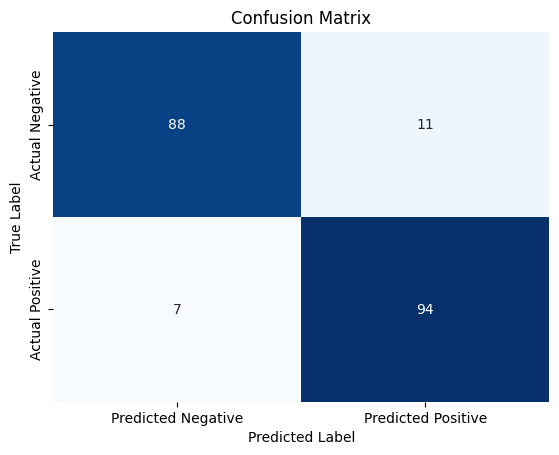


--- Feature Importances from Random Forest ---


/tmp/ipykernel_560/3034350135.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importances.values, y=sorted_importances.index, palette='viridis')


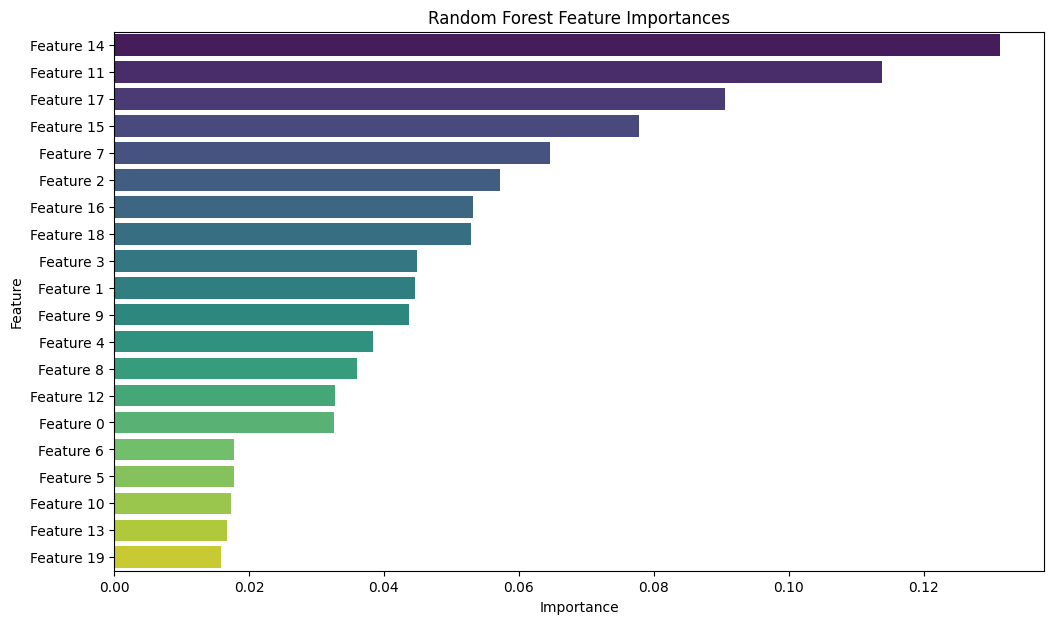

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set using the trained chosen_model (Random Forest)
y_pred = chosen_model.predict(X_test)

print("--- Classification Report on Test Set ---")
print(classification_report(y_test, y_pred, zero_division=0))

print("--- Confusion Matrix on Test Set ---")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\n--- Feature Importances from Random Forest ---")
# Assuming X has feature names, or we can use generic names
# For synthetic data, we don't have explicit names, so we'll use F0, F1, etc.
feature_names = [f'Feature {i}' for i in range(X.shape[1])]
feature_importances = pd.Series(chosen_model.feature_importances_, index=feature_names)

# Sort feature importances for better visualization
sorted_importances = feature_importances.sort_values(ascending=False)

# Plotting feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x=sorted_importances.values, y=sorted_importances.index, palette='viridis')
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.